#### Imports

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from pathlib import Path
import pickle
import warnings
import os
from typing import Dict, List, Tuple, Optional

warnings.filterwarnings('ignore')

# Import KMRF class
from kama_msr import KAMA_MSR
from kmrf import KMRF
from KMRF_training_config import *

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported successfully")
print(f"  Pandas version: {pd.__version__}")
print(f"  NumPy version: {np.__version__}")

from pandas.tseries.holiday import USFederalHolidayCalendar
from pandas.tseries.offsets import CustomBusinessDay

TRADING_DAYS = CustomBusinessDay(calendar=USFederalHolidayCalendar())

✓ Libraries imported successfully
  Pandas version: 2.3.3
  NumPy version: 2.3.4


## Load Master Data for Feature Access

In [7]:
# Load master data once to get all available trading dates
master_df_path = Path('data/master_df.csv')
master_df = pd.read_csv(master_df_path, index_col=0, header=[0, 1, 2], parse_dates=True)
master_df.index = pd.to_datetime(master_df.index)

# Get all trading dates from the data
all_trading_dates = master_df.index.tolist()

print(f"Master data loaded")
print(f"Total trading dates: {len(all_trading_dates)}")
print(f"Date range: {all_trading_dates[0].date()} to {all_trading_dates[-1].date()}")

Master data loaded
Total trading dates: 9051
Date range: 1990-01-03 to 2025-10-31


## Configuration

In [39]:
# Configuration
ASSET_CLASS = 'us_equity'
BASE_MODEL_PATH = Path('saved_models/KAMA_MSR') / ASSET_CLASS

print(f"Asset Class: {ASSET_CLASS}")
print(f"Model Path: {BASE_MODEL_PATH}")

Asset Class: us_equity
Model Path: saved_models/KAMA_MSR/us_equity


In [40]:
km_model_files = sorted(list((BASE_MODEL_PATH / '20251007').glob('*.pkl')))
preds_files = sorted(list(Path('data/multi_horizon_predictions').glob('*'))
                     )
asset_names= [f.stem.split('multi')[0][:-1].replace('_', ' ') for f in preds_files]

In [41]:
pd.DataFrame(asset_names)

,0
0,Consumer Discretionary Select Sector SPDR
1,Consumer Staples Select Sector SPDR
2,Energy Select Sector SPDR
3,Financial Select Sector SPDR
4,GraniteShares Platinum Trust
5,Health Care Select Sector SPDR
6,Industrial Select Sector SPDR
7,Invesco DB Agriculture
8,Invesco DB Base Metals
9,Invesco QQQ Trust


## Plotting Preds vs. Actuals

In [66]:
def plot_predicted_regimes(km_model: KAMA_MSR, preds: pd.DataFrame, 
                           asset_name: str, H: int = 1):

    # h1_preds = preds[preds.index.get_level_values('horizon') == 1].droplevel('horizon').drop(columns='model_end_date')\
    # .apply(lambda row: row.idxmax(), axis=1)\
    #     .map({'P(LV_Bull)': 0, 'P(LV_Bear)': 1, 'P(HV_Bull)': 2, 'P(HV_Bear)': 3})
    pred_dates = preds.index.get_level_values(0).unique()

    preds['pred_date'] = preds.index.map(lambda x: pred_dates[pred_dates.get_loc(x[0]) + (x[1]-1)]
                    if pred_dates.get_loc(x[0]) + (x[1]-1) < len(pred_dates)
                    else x[0] + x[1] * TRADING_DAYS)
    preds.set_index('pred_date', append=True, inplace=True)

    H_preds = preds[preds.index.get_level_values('horizon') == H].droplevel(0).droplevel(0).drop(columns='model_end_date')\
        .apply(lambda row: row.idxmax(), axis=1)\
            .map({'P(LV_Bull)': 0, 'P(LV_Bear)': 1, 'P(HV_Bull)': 2, 'P(HV_Bear)': 3})

    prices_plot = km_model.prices.loc[H_preds.index.min():H_preds.index.max()].copy()
    kama_plot = km_model.kama_values.loc[H_preds.index.min():H_preds.index.max()].copy()
    regime_preds_plot = H_preds.loc[prices_plot.index].copy()

    fig, axes = plt.subplots(2, 1, figsize=(16,8), gridspec_kw={'height_ratios': [2, 1]})

    colors = {0: 'green', 1: 'royalblue', 2: 'orange', 3: 'darkred'}
    regime_names = {0: 'LV Bull', 1: 'LV Bear', 2: 'HV Bull', 3: 'HV Bear'}

    # Plot 1: Price and KAMA
    ax1 = axes[0]
    ax1.plot(prices_plot.index, prices_plot, label='Price', 
            color='black', alpha=0.7, linewidth=1)
    ax1.plot(kama_plot.index, kama_plot, 
            label='KAMA', color='blue', linewidth=2)

    for regime in range(4):
        mask = (regime_preds_plot == regime)
        if mask.any():
            mask_aligned = pd.Series(False, index=prices_plot.index)
            mask_aligned.loc[regime_preds_plot.index[mask]] = True
            
            ax1.fill_between(prices_plot.index, prices_plot.min(), prices_plot.max(),
                            where=mask_aligned.values, alpha=0.2, color=colors[regime],
                            label=regime_names[regime])

    # Add date range to title
    date_range_str = f" ({prices_plot.index[0].strftime('%Y-%m-%d')} to {prices_plot.index[-1].strftime('%Y-%m-%d')})"
    ax1.set_title(f'{asset_name}: Price and KAMA with {H}d Fwd Regime Predictions{date_range_str}')
    ax1.set_ylabel('Price')
    ax1.legend(loc='best', ncol=2)
    ax1.grid(True, alpha=0.3)

    # Plot 2: Regime Classification
    ax4 = axes[1]
    for regime in range(4):
        mask = (regime_preds_plot == regime)
        if mask.any():
            ax4.scatter(regime_preds_plot.index[mask], regime_preds_plot[mask],
                        c=colors[regime], label=regime_names[regime], alpha=0.6, s=10)

    ax4.set_title(f'{asset_name}: 1d Fwd Regime Predictions')
    ax4.set_ylabel('Regime')
    ax4.set_yticks(list(range(4)))
    ax4.set_yticklabels([regime_names[i] for i in range(4)])
    ax4.legend(loc='best', ncol=2)
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return H_preds.index.min(), H_preds.index.max(), regime_preds_plot


In [67]:
# asset_name_match = "SPDR S&P 500 ETF" # Specify the asset name to match
asset_name_match = asset_names[17]
HORIZON = 1

for path in preds_files:
    if asset_name_match.replace(" ", "_") in path.stem: # asset names have underscores in preds files
        preds_path = path
        print(preds_path)
        break

for path in km_model_files:
    if asset_name_match in path.stem:
        km_model_file = path
        asset_name = km_model_file.stem.split('_')[0]
        print(km_model_file)
        print(asset_name)
        break

preds = pd.read_pickle(preds_path)
km_model = pickle.load(open(km_model_file, 'rb'))

data/multi_horizon_predictions/Teucrium_Sugar_Fund_multi_horizon_predictions_original.pkl
saved_models/KAMA_MSR/us_equity/20251007/Teucrium Sugar Fund_KAMA-MSR_4-regimes.pkl
Teucrium Sugar Fund


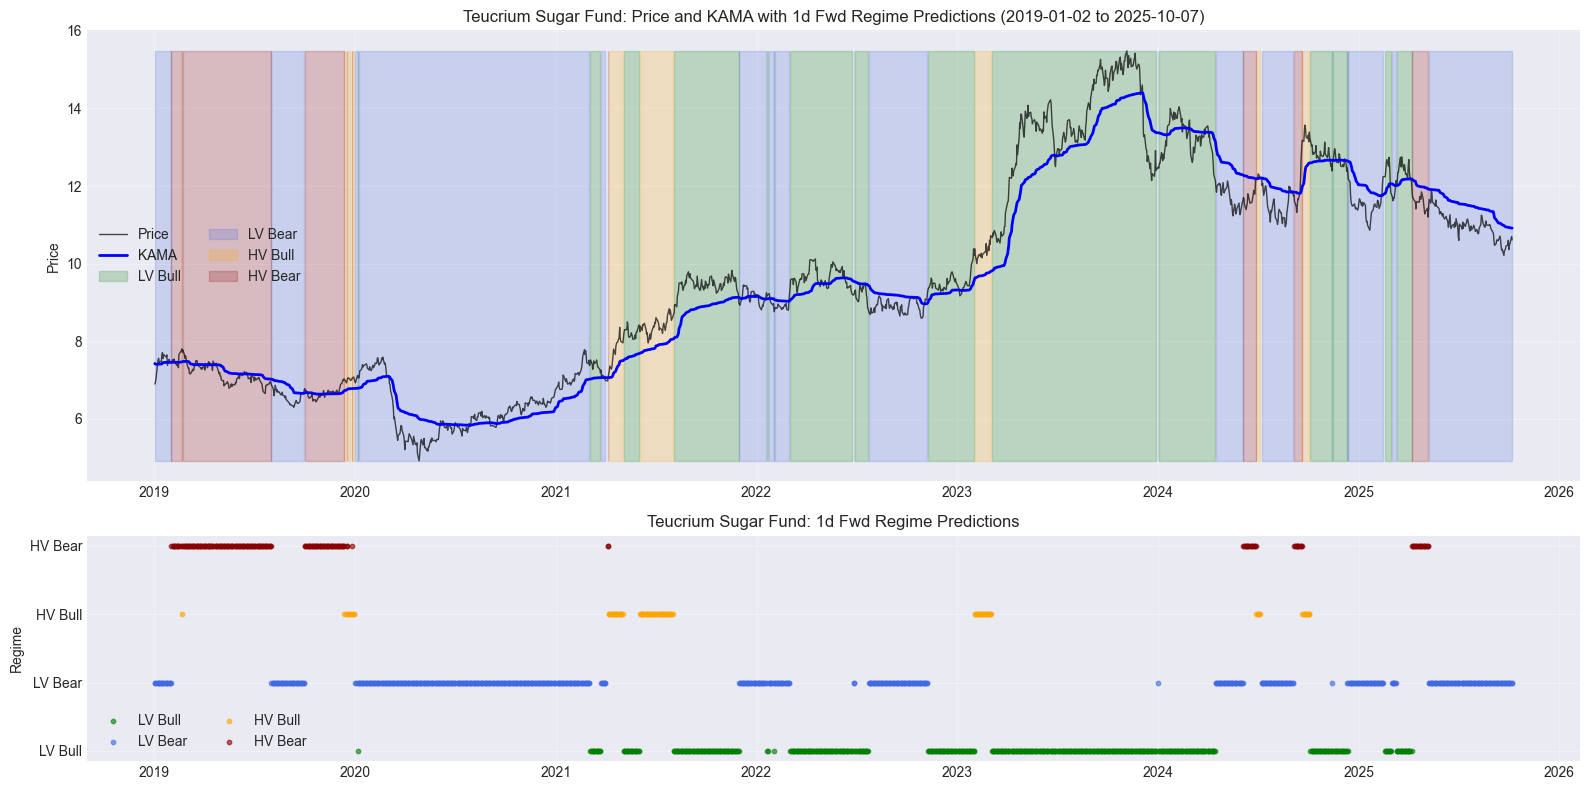

In [68]:
sdte, edte, regime_preds = plot_predicted_regimes(km_model, preds, asset_name, H=HORIZON)

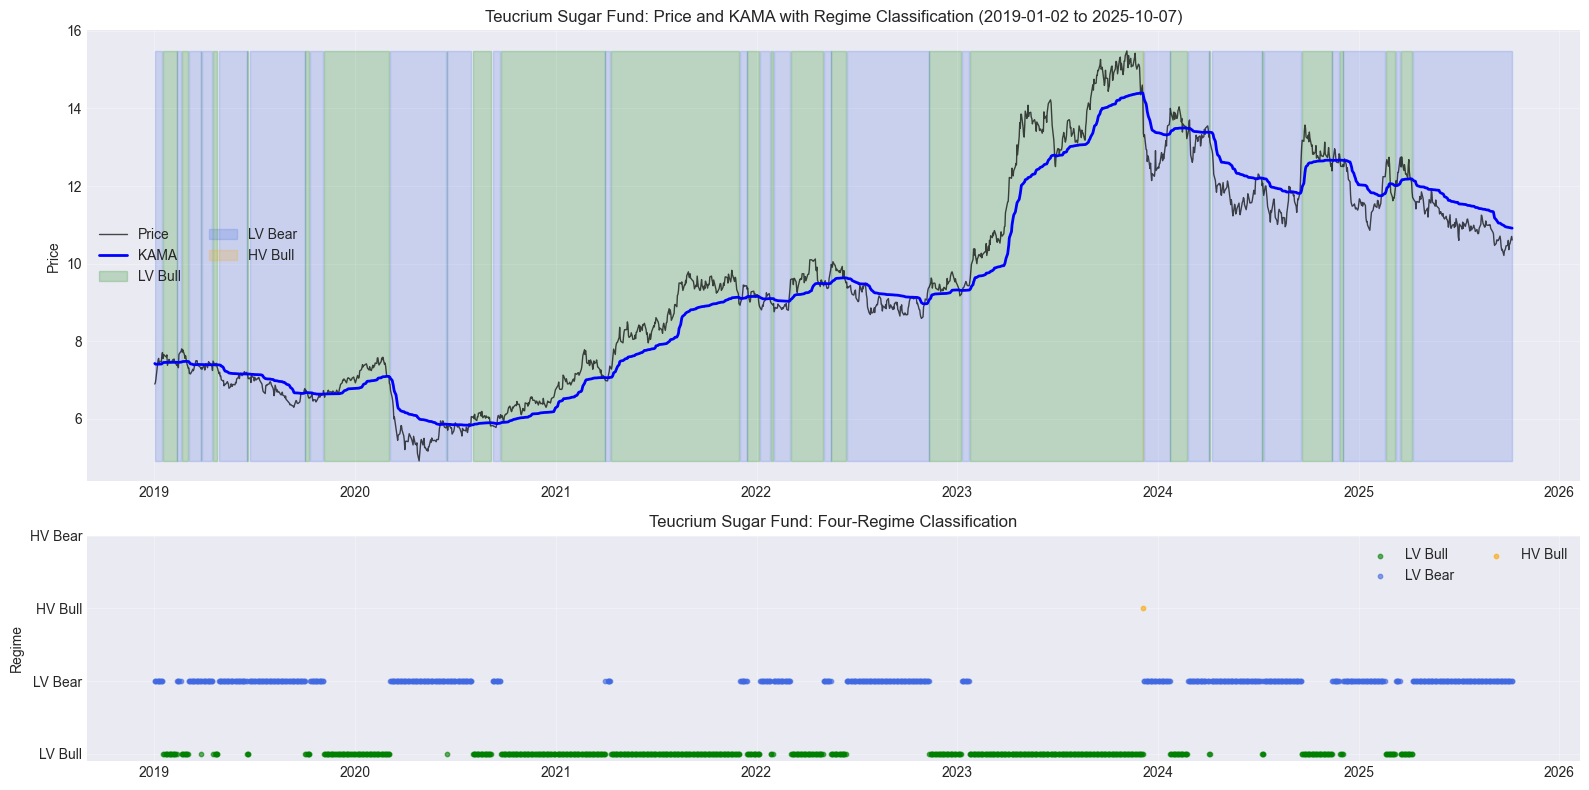

In [69]:
km_model.plot_regimes(data_name=asset_name, 
                      start_date=sdte, end_date=edte)

## Get Fwd Prediction Accuracies

In [15]:
def get_Hd_fwd_accuracy(km_model: KMRF, preds: pd.Series, H: int) -> float:
    pred_dates = preds.index.get_level_values(0).unique()

    preds['pred_date'] = preds.index.map(lambda x: pred_dates[pred_dates.get_loc(x[0]) + (x[1]-1)]
                    if pred_dates.get_loc(x[0]) + (x[1]-1) < len(pred_dates)
                    else x[0] + x[1] * TRADING_DAYS)
    preds.set_index('pred_date', append=True, inplace=True)

    H_preds = preds[preds.index.get_level_values('horizon') == H].droplevel(0).droplevel(0).drop(columns='model_end_date')\
        .apply(lambda row: row.idxmax(), axis=1)\
            .map({'P(LV_Bull)': 0, 'P(LV_Bear)': 1, 'P(HV_Bull)': 2, 'P(HV_Bear)': 3})
    
    actual_regimes = km_model.regime_labels.loc[H_preds.index.min():H_preds.index.max()]
    H_preds = H_preds.loc[actual_regimes.index]
    correct_predictions = (H_preds == actual_regimes)
    accuracy = correct_predictions.mean()
    return accuracy

def get_all_Hd_fwd_accuracies(H: int):
    pred_accuracies_Hd_fwd = {}

    for i in range(len(asset_names)):
        asset_name_match = asset_names[i]

        for path in preds_files:
            if asset_name_match.replace(" ", "_") in path.stem: # asset names have underscores in preds files
                preds_path = path
                # print(preds_path)
                break

        for path in km_model_files:
            if asset_name_match in path.stem:
                km_model_file = path
                asset_name = km_model_file.stem.split('_')[0]
                # print(km_model_file)
                # print(asset_name)
                break

        preds = pd.read_pickle(preds_path)
        km_model = pickle.load(open(km_model_file, 'rb'))

        pred_accuracies_Hd_fwd[asset_name] = get_Hd_fwd_accuracy(km_model, preds, H=H)

    acc = pd.DataFrame.from_dict(pred_accuracies_Hd_fwd, orient='index', columns=[f'{H}d Fwd Accuracy'])\
        .sort_index()
    
    return acc


In [16]:
all_Hd_accs = []
for H in [1, 5, 10, 21]:
    Hd_acc = get_all_Hd_fwd_accuracies(H=H)
    all_Hd_accs.append(Hd_acc)

all_acc = pd.concat(all_Hd_accs, axis=1)

In [ ]:
# all_acc.sort_values(by='1d Fwd Accuracy', ascending=False).to_csv('data/kmrf_fwd_regime_accuracies.csv')

In [81]:
all_acc.sort_values(by='5d Fwd Accuracy', ascending=False)

,1d Fwd Accuracy,5d Fwd Accuracy,10d Fwd Accuracy,21d Fwd Accuracy
SPDR Dow Jones Industrial Average ETF,0.933568,0.925162,0.905437,0.847115
iShares Russell Mid-Cap ETF,0.947090,0.921626,0.896572,0.826294
SPDR S&P 500 ETF,0.929453,0.921037,0.910165,0.881618
Consumer Staples Select Sector SPDR,0.946502,0.918091,0.866430,0.740631
Financial Select Sector SPDR,0.932981,0.915144,0.844563,0.760857
Industrial Select Sector SPDR,0.928277,0.914555,0.901300,0.832243
iShares S&P 500 Value ETF,0.924750,0.912198,0.877069,0.828673
iShares S&P 100 ETF,0.928865,0.909841,0.878842,0.834027
Health Care Select Sector SPDR,0.902410,0.909252,0.887116,0.809637
Materials Select Sector SPDR,0.923574,0.906305,0.858747,0.744200
